# BrushCue Example: Vibrancy

<a href="https://colab.research.google.com/github/ditotechnologies/brushcue/blob/main/examples/vibrancy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

You can use this tool online at https://www.brushcue.com/tools/vibrancy

In [ ]:
!pip install brushcue

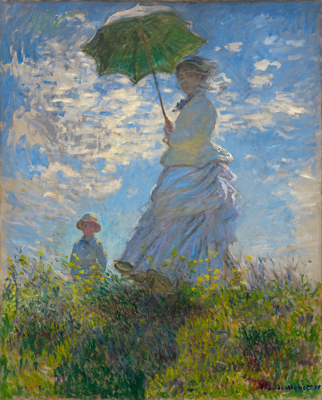

In [1]:
import brushcue
from PIL import Image
import io

input_image_1 = brushcue.composition_monet_women_with_parasol() # insert your own image here
string_constant_2 = brushcue.string_constant("\n  let l = input.x;\n  let a = input.y;\n  let b = input.z;\n  let alpha = input.w;\n  let chroma = sqrt(a * a + b * b);\n  let vibrance_boost = vibrance_boost;\n  let saturation_factor = 1.0 - pow(chroma, 0.5);\n  let adaptive_boost = mix(vibrance_boost, 1.0, saturation_factor);\n  let boosted_chroma = chroma * adaptive_boost;\n  let hue = atan2(b, a);\n  let new_a = cos(hue) * boosted_chroma;\n  let new_b = sin(hue) * boosted_chroma;\n  return vec4<f32>(l, new_a, new_b, alpha);")
string_constant_3 = brushcue.string_constant("\n// You can write your helper functions here if you need them.")
color_profile_oklaba_4 = brushcue.color_profile_ok_lab_a()
color_profile_oklaba_5 = brushcue.color_profile_ok_lab_a()
bool_constant_6 = brushcue.bool_constant(False)
dictionary_create_7 = brushcue.dictionary_create()
string_constant_8 = brushcue.string_constant("vibrance_boost")
float_constant_9 = brushcue.float_constant(2.0)
boost_10 = brushcue.float_passthrough(float_constant_9)
float_add_to_dictionary_11 = brushcue.float_add_to_dictionary(dictionary_create_7, string_constant_8, boost_10)
vibrancy_effect_12 = brushcue.composition_custom_transformer_shader(input_image_1, string_constant_2, string_constant_3, color_profile_oklaba_4, color_profile_oklaba_5, float_add_to_dictionary_11, bool_constant_6)

ctx = brushcue.Context()
result = vibrancy_effect_12.execute(ctx)
composition = result.as_composition()
data_bytes = composition.to_image_bytes(ctx)
img = Image.open(io.BytesIO(data_bytes))
img.thumbnail((400, 400)) # remove this line for full resolution
img
